Accuracy: 0.8022540983606558

Classification Report:
               precision    recall  f1-score   support

    negative       0.83      0.94      0.88      1835
     neutral       0.68      0.56      0.62       620
    positive       0.83      0.57      0.67       473

    accuracy                           0.80      2928
   macro avg       0.78      0.69      0.72      2928
weighted avg       0.80      0.80      0.79      2928



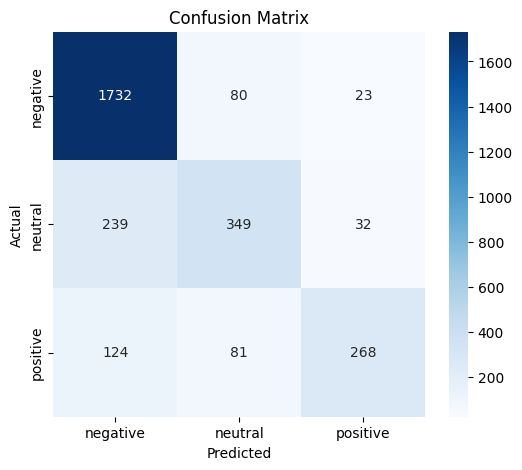

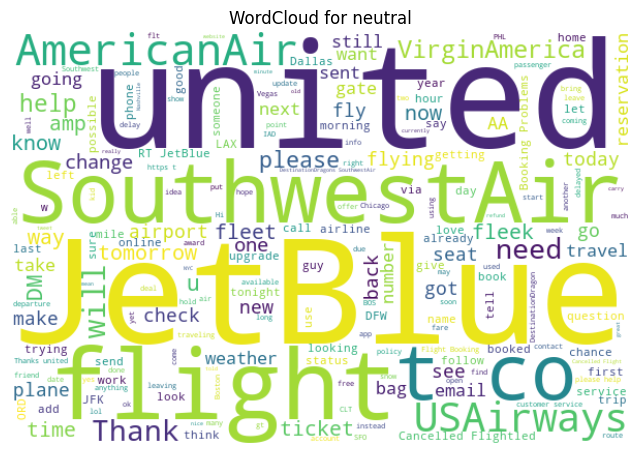

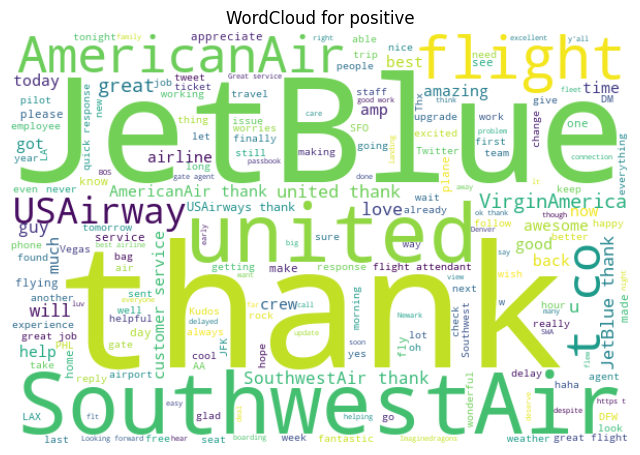

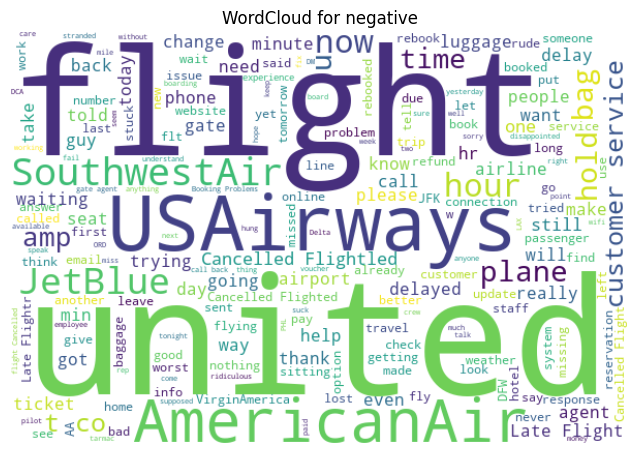

✅ Model saved as ../models/sentiment_model.pkl


In [13]:
# 05_model_training.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# 1. Load dataset
df = pd.read_csv("../data/Tweets_clean.csv")

# 2. Standardize column names (fix KeyError issue)
df.columns = [c.lower().strip() for c in df.columns]

# Rename sentiment column properly
if "sentiment" not in df.columns:
    if "airline_sentiment" in df.columns:
        df.rename(columns={"airline_sentiment": "sentiment"}, inplace=True)
    elif "label" in df.columns:
        df.rename(columns={"label": "sentiment"}, inplace=True)

# 3. Drop rows with missing values
df = df.dropna(subset=["text", "sentiment"])
df["text"] = df["text"].fillna("")

# 4. Train-test split
X = df["text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Build pipeline
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=1000))
])

# 6. Train model
pipeline.fit(X_train, y_train)

# 7. Evaluate model
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 8. WordClouds per sentiment
for sentiment in df["sentiment"].unique():
    text = " ".join(df[df["sentiment"] == sentiment]["text"].astype(str))
    wc = WordCloud(width=600, height=400, background_color="white").generate(text)
    plt.figure(figsize=(8,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud for {sentiment}")
    plt.show()

# 9. Save model
joblib.dump(pipeline, "../models/sentiment_model.pkl")
print("✅ Model saved as ../models/sentiment_model.pkl")
